In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay,classification_report
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras





# Load the dataset
url = #path to dataset in eg r'/Users/Jonny/Desktop/ai_assignment_dataset/Telco-Customer-Churn.csv format 




#PATH TO DATASET



customers = pd.read_csv(url)




print("Dataset preview:\n", customers.head())











3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]
Dataset preview:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic 

In [65]:
#Drope ID category




#drop ID category
customers.drop(columns=['customerID'], axis = 1,inplace=True) # Removing ID as it has no relevance to inference








print(customers.columns) 





Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [66]:
#White spaces in total charges


#white space counter in Total charges
non_numeric_mask = customers['TotalCharges'].astype(str).str.match(r'^\s*$')


count_of_bad_entries = non_numeric_mask.sum()

print(f"Total number of entries in 'TotalCharges' that are empty or only whitespace: {count_of_bad_entries}")





#convert all the values to Zero
customers['TotalCharges'] = pd.to_numeric(customers['TotalCharges'], errors='coerce')

# Fill the NaN values with 0


customers.fillna({'TotalCharges': 0}, inplace=True)




Total number of entries in 'TotalCharges' that are empty or only whitespace: 11


In [67]:
#------Encoding-----------#
#binary cateogries

# Binary columns to encode 
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    customers[col] = customers[col].replace({'Yes': 1, 'No': 0}).astype(int)

# Handle the 'gender' column separately (e.g., Male=1, Female=0)
customers['gender'] = customers['gender'].replace({'Male': 1, 'Female': 0}).astype(int)

# The original object columns are now numerical (0 or 1). No duplication occurs.

print(customers.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


/var/folders/7d/4kr0rhyx2c54f0j22w880vvc0000gp/T/ipykernel_82393/70262319.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customers[col] = customers[col].replace({'Yes': 1, 'No': 0}).astype(int)
/var/folders/7d/4kr0rhyx2c54f0j22w880vvc0000gp/T/ipykernel_82393/70262319.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customers[col] = customers[col].replace({'Yes': 1, 'No': 0}).astype(int)
/var/folders/7d/4kr0rhyx2c54f0j22w880vvc0000gp/T/ipykernel_82393/70262319.py:8: FutureWarning: Downcasting behavior in `replace` is deprec

In [68]:

import pandas as pd

# The columns you provided
cols_to_encode = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod',
]

# Apply one-hot encoding, dropping the first category to avoid multicollinearity 
# WHAT Is it two or more predictor variables (features) in a regression model are highly correlated with each other.
customers = pd.get_dummies(
    customers,
    columns=cols_to_encode,
    dtype=int,
    drop_first=True
)

print(customers.info()) # Now prints info of the encoded DataFrame






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [69]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


y = customers['Churn']   #feature we are trying to predict 
X = customers.drop('Churn', axis=1)   #the rest of the data without Y


# Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
#startify beacuse the proportion of churn is much less 







numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 2. Initialize the StandardScaler
scaler = StandardScaler()



#SCALING 


# 3. FIT AND TRANSFORM the Training Data 
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features]) #scales the numerical values 



# 4. TRANSFORM the Testing Data 
X_test[numerical_features] = scaler.transform(X_test[numerical_features])  


print("Standardization Complete!")

print(f"Mean of 'tenure' in X_train_scaled: {X_train['TotalCharges'].mean():.2f}")
print(f"Standard Deviation of 'tenure' in X_train_scaled: {X_train['TotalCharges'].std():.2f}")



Standardization Complete!
Mean of 'tenure' in X_train_scaled: 0.00
Standard Deviation of 'tenure' in X_train_scaled: 1.00


In [70]:
# Create feature matrix X without label column 'Churn'
X = customers.drop('Churn',axis = 'columns')
# Create label vector y
y = customers['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)









In [71]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(38, input_shape= (30,), activation= 'relu'),
    tf.keras.layers.Dense(14, activation= 'relu'),
    tf.keras.layers.Dense(1, activation= 'sigmoid')     
])

model.compile(optimizer= 'adam',
             loss='binary_crossentropy',
             metrics=['accuracy'])









/Users/Jonny/opt/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [72]:
model.fit(X_train, y_train, epochs= 50)

Epoch 1/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 373us/step - accuracy: 0.6656 - loss: 7.9772    
Epoch 2/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.7297 - loss: 1.1250
Epoch 3/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - accuracy: 0.7558 - loss: 0.7706
Epoch 4/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - accuracy: 0.7547 - loss: 0.8617
Epoch 5/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.7455 - loss: 1.2590
Epoch 6/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.7591 - loss: 0.7964
Epoch 7/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.7373 - loss: 1.2721
Epoch 8/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.7529 - loss: 0.8661
Epoch 9/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - accuracy: 0.7639 - loss: 0.8075
Epoch 10/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.7492 - loss: 1.3377
Epoch 11/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - accuracy: 0.7561 - loss: 0.8892
Epoch 12/50
177/177 ━━━━━━

In [73]:
model.evaluate(X_test, y_test)

y_pred_probs = model.predict(X_test)

y_pred_binary = np.where(y_pred_probs > 0.5, 1, 0)


# 3. Ensure the result is an integer type (fixes the 'continuous' mix-up)
y_pred = y_pred_binary.astype(int)

# 4. Ensure the shape is a flat, 1D array (necessary for scikit-learn metrics)
# This removes the extra dimension Keras/TensorFlow often adds.
y_pred = y_pred.flatten()   

# 5. Run the report
print(classification_report(y_test, y_pred))




#y_pred = model.predict(X_test)









45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - accuracy: 0.7991 - loss: 0.4760
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1036
           1       0.69      0.44      0.54       373

    accuracy                           0.80      1409
   macro avg       0.76      0.68      0.70      1409
weighted avg       0.79      0.80      0.78      1409



              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1036
           1       0.69      0.44      0.54       373

    accuracy                           0.80      1409
   macro avg       0.76      0.68      0.70      1409
weighted avg       0.79      0.80      0.78      1409



<Figure size 600x600 with 0 Axes>

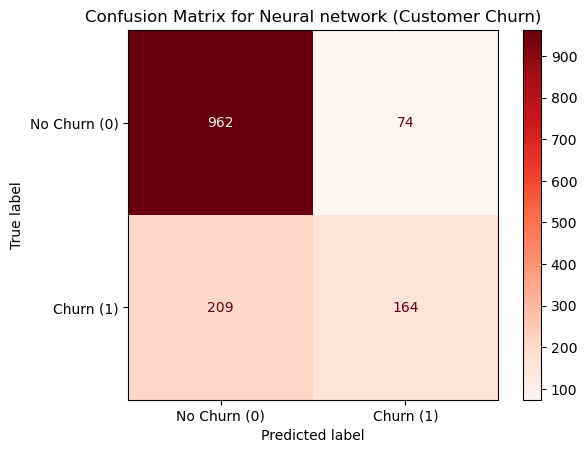

In [74]:
print(classification_report(y_test,y_pred))





# 1. Random Forest predictions
# We use the unique values in y_test to define the labels (0 and 1)
cm_rf = confusion_matrix(y_test, y_pred, labels=[0, 1])

# 2. Visualize the Confusion Matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn (0)', 'Churn (1)'])

plt.figure(figsize=(6, 6)) # Define figure size before plotting
disp_rf.plot(cmap=plt.cm.Reds, values_format='d')
plt.title('Confusion Matrix for Neural network (Customer Churn)')
plt.show() 










